In [3]:
! pip install pandas matplotlib seaborn wordcloud datasets

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
from wordcloud import WordCloud
import ast

In [5]:
# Set aesthetics for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Loading dataset...")
dataset = load_dataset("newfacade/LeetCodeDataset")

Loading dataset...


In [6]:
# Convert splits to Pandas DataFrames
df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()

# Add a label to keep track of splits if merged
df_train['split'] = 'train'
df_test['split'] = 'test'
df_all = pd.concat([df_train, df_test], ignore_index=True)

print(f"Data Loaded: Train shape = {df_train.shape}, Test shape = {df_test.shape}")

# ==========================================
# 2. FEATURE ENGINEERING & DATA CLEANING
# ==========================================
def clean_tags(tag_entry):
    """Safely converts string representations of lists or arrays into clean Python lists."""
    if isinstance(tag_entry, np.ndarray) or isinstance(tag_entry, list):
        return list(tag_entry)
    if isinstance(tag_entry, str):
        try:
            return ast.literal_eval(tag_entry)
        except (ValueError, SyntaxError):
            return [tag_entry.strip("[]'\" ")]
    return []

Data Loaded: Train shape = (2641, 15), Test shape = (228, 15)


In [7]:
# Apply cleaning and feature generation
for df in [df_train, df_test, df_all]:
    df['tags_clean'] = df['tags'].apply(clean_tags)
    df['num_tags'] = df['tags_clean'].apply(len)

    # Calculate lengths of text fields for capacity and token estimation
    df['desc_length'] = df['problem_description'].fillna('').apply(len)
    df['prompt_length'] = df['prompt'].fillna('').apply(len)
    df['completion_length'] = df['completion'].fillna('').apply(len)
    df['query_length'] = df['query'].fillna('').apply(len)
    df['response_length'] = df['response'].fillna('').apply(len)

    # Structural features
    df['starter_code_lines'] = df['starter_code'].fillna('').apply(lambda x: len(x.splitlines()))
    df['completion_lines'] = df['completion'].fillna('').apply(lambda x: len(x.splitlines()))

    # Convert estimated date to Datetime
    df['estimated_date'] = pd.to_datetime(df['estimated_date'], errors='coerce')
    df['release_year'] = df['estimated_date'].dt.year

Text(0, 0.5, 'Count')

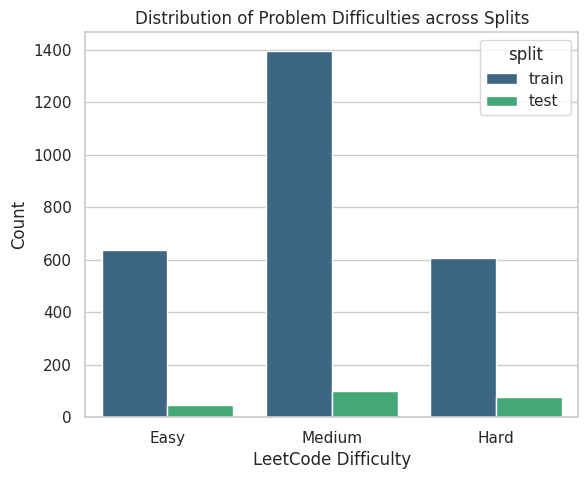

In [8]:
# ==========================================
# 4. EXPLORATORY VISUALIZATIONS
# ===========================================
# Chart 1: Split Distribution & Problem Difficulty
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
order = ['Easy', 'Medium', 'Hard']
sns.countplot(data=df_all, x='difficulty', hue='split', order=order, palette='viridis')
plt.title('Distribution of Problem Difficulties across Splits')
plt.xlabel('LeetCode Difficulty')
plt.ylabel('Count')

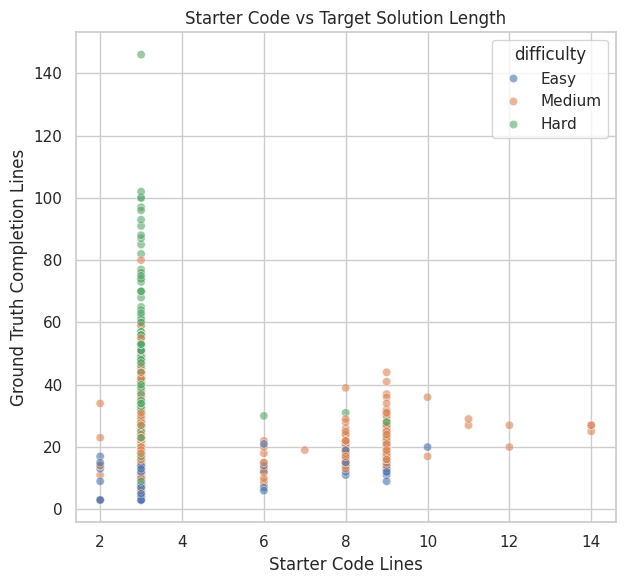

In [9]:
# Chart 2: Code Expansion (Starter vs Completed Code)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_all, x='starter_code_lines', y='completion_lines', hue='difficulty', alpha=0.6, hue_order=order)
plt.title('Starter Code vs Target Solution Length')
plt.xlabel('Starter Code Lines')
plt.ylabel('Ground Truth Completion Lines')
plt.tight_layout()
plt.show()

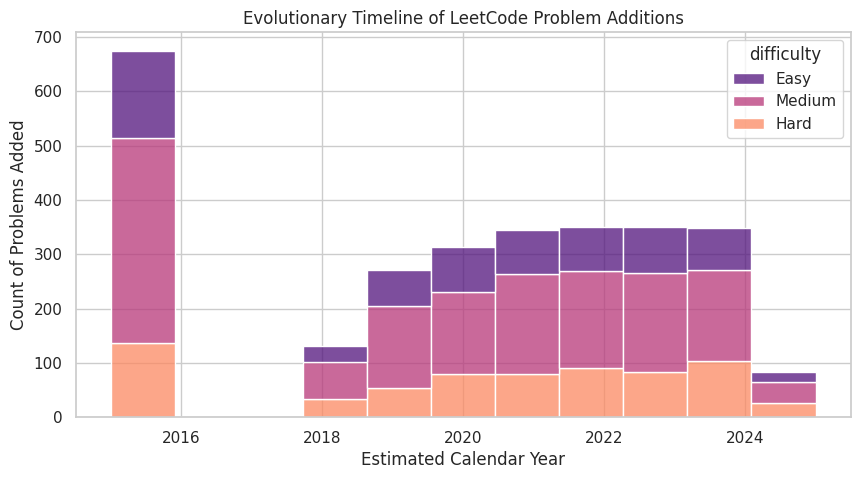

In [10]:
# Chart 3: Problem Timeline / Evolution Over Years
plt.figure(figsize=(10, 5))
sns.histplot(data=df_all.dropna(subset=['release_year']), x='release_year', hue='difficulty', multiple='stack', bins=int(df_all['release_year'].max() - df_all['release_year'].min() + 1), hue_order=order, palette='magma')
plt.title('Evolutionary Timeline of LeetCode Problem Additions')
plt.xlabel('Estimated Calendar Year')
plt.ylabel('Count of Problems Added')
plt.show()

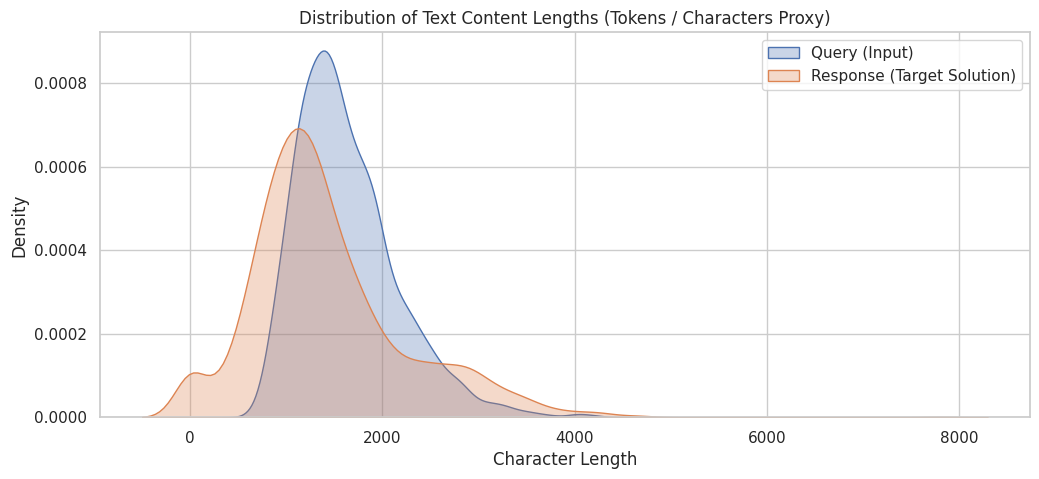

In [11]:
# Chart 4: SFT Text Fields Length Distributions
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df_all, x='query_length', label='Query (Input)', fill=True, alpha=0.3)
sns.kdeplot(data=df_all, x='response_length', label='Response (Target Solution)', fill=True, alpha=0.3)
plt.title('Distribution of Text Content Lengths (Tokens / Characters Proxy)')
plt.xlabel('Character Length')
plt.ylabel('Density')
plt.legend()
plt.show()

In [12]:
# ==========================================
# 5. ALGORITHMIC TAG ANALYSIS
# ==========================================
print("\n=== TOP LOGICAL ALGORITHMIC TOPICS ===")
all_tags = [tag for sublist in df_all['tags_clean'] for tag in sublist if tag]
tag_counts = Counter(all_tags)
top_tags_df = pd.DataFrame(tag_counts.most_common(15), columns=['Algorithmic Tag', 'Frequency'])
print(top_tags_df)


=== TOP LOGICAL ALGORITHMIC TOPICS ===
         Algorithmic Tag  Frequency
0                  Array       1769
1                 String        734
2             Hash Table        591
3    Dynamic Programming        563
4                   Math        532
5                Sorting        433
6                 Greedy        399
7          Binary Search        271
8     Depth-First Search        269
9                 Matrix        240
10      Bit Manipulation        228
11  Breadth-First Search        214
12          Two Pointers        203
13                  Tree        193
14            Prefix Sum        189


/tmp/ipykernel_10634/1426520605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tags_df, y='Algorithmic Tag', x='Frequency', palette='coolwarm')


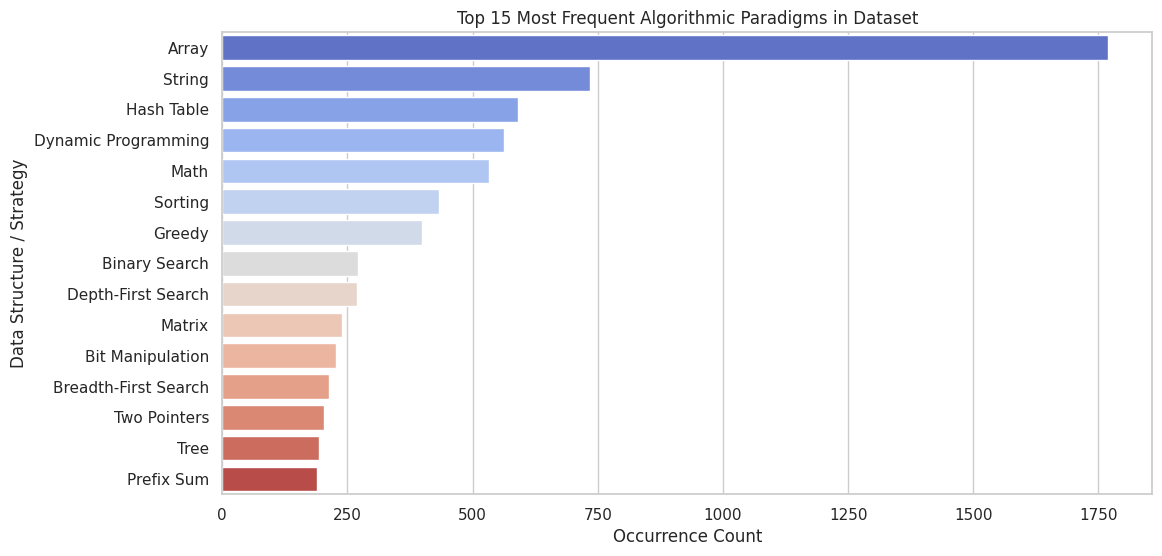

In [13]:
# Chart 5: Barplot of Top Tags
plt.figure(figsize=(12, 6))
sns.barplot(data=top_tags_df, y='Algorithmic Tag', x='Frequency', palette='coolwarm')
plt.title('Top 15 Most Frequent Algorithmic Paradigms in Dataset')
plt.xlabel('Occurrence Count')
plt.ylabel('Data Structure / Strategy')
plt.show()

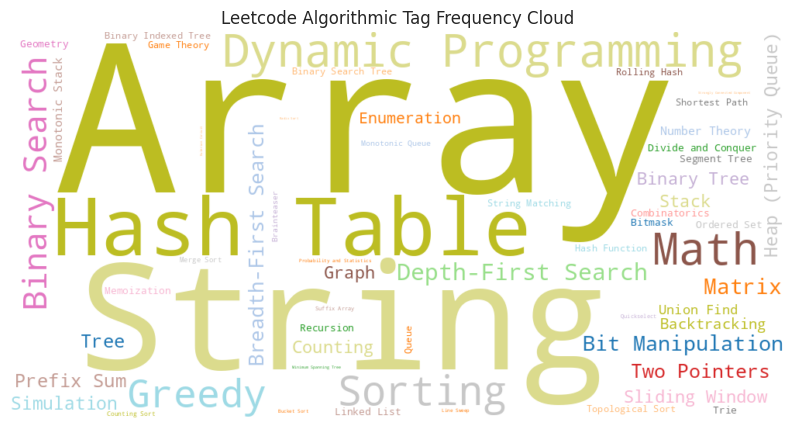

In [14]:
# Chart 6: WordCloud of Problem Themes
plt.figure(figsize=(10, 6))
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='tab20').generate_from_frequencies(tag_counts)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Leetcode Algorithmic Tag Frequency Cloud')
plt.show()

In [15]:
# ==========================================
# 6. SFT CONTEXT WINDOW PROFILE
# ==========================================
print("\n=== CONTEXT WINDOW RECOMMENDATIONS FOR LLM TRAINING ===")
combined_sft_len = df_train['query_length'] + df_train['response_length']
p95 = combined_sft_len.quantile(0.95)
p99 = combined_sft_len.quantile(0.99)
max_len = combined_sft_len.max()

print(f"95th Percentile of Full Query+Response Character Length: {p95:.1f}")
print(f"99th Percentile of Full Query+Response Character Length: {p99:.1f}")
print(f"Absolute Maximum Sequence Character Length: {max_len}")

# Estimating token equivalents (Rule of thumb: 1 token ≈ 4 characters for raw text and code)
print(f"--> Recommended MAX_SEQ_LENGTH configuration for training: {int(np.ceil(p99 / 4.0)) if p99/4.0 < 4096 else 4096} tokens.")


=== CONTEXT WINDOW RECOMMENDATIONS FOR LLM TRAINING ===
95th Percentile of Full Query+Response Character Length: 5133.0
99th Percentile of Full Query+Response Character Length: 6199.0
Absolute Maximum Sequence Character Length: 9109
--> Recommended MAX_SEQ_LENGTH configuration for training: 1550 tokens.



=== TOP LOGICAL ALGORITHMIC TOPICS BY DIFFICULTY ===


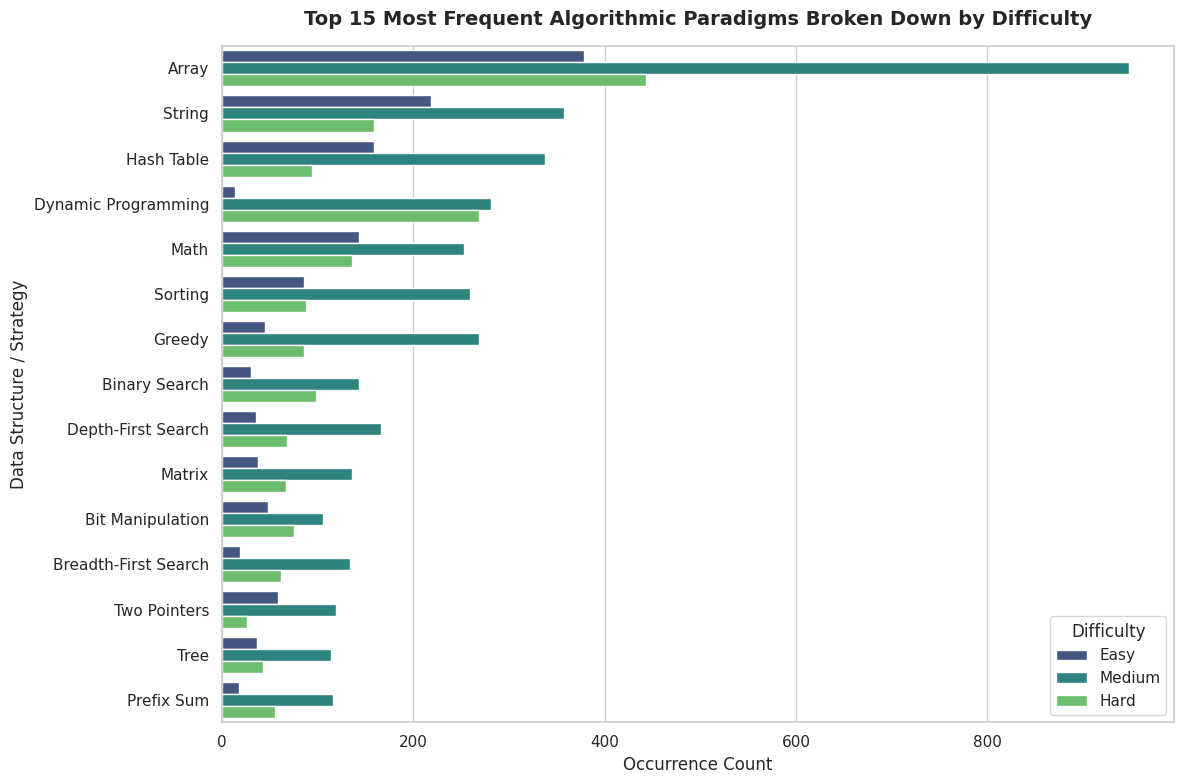

In [16]:
# ==========================================
print("\n=== TOP LOGICAL ALGORITHMIC TOPICS BY DIFFICULTY ===")

# 1. Explode the clean tags list to give each individual tag its own row while keeping its difficulty
df_exploded = df_all.explode('tags_clean')

# 2. Filter out any empty, null, or blank tags
df_exploded = df_exploded[df_exploded['tags_clean'].notna() & (df_exploded['tags_clean'] != '')]

# 3. Identify the top 15 most frequent tags overall to maintain a clean vertical axis order
top_15_tags = df_exploded['tags_clean'].value_counts().head(15).index

# 4. Filter the exploded dataframe to only include these top 15 tags
df_top_tags = df_exploded[df_exploded['tags_clean'].isin(top_15_tags)]

# 5. Create the grouped horizontal barplot
fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(
    data=df_top_tags,
    y='tags_clean',
    hue='difficulty',
    order=top_15_tags,                        # Keeps bars sorted by overall frequency
    hue_order=['Easy', 'Medium', 'Hard'],     # Standardizes the color group sequence
    palette='viridis',                        # High contrast, clean palette
    ax=ax
)

# Refine labels and aesthetics to ensure text is non-overlapping and readable
ax.set_title('Top 15 Most Frequent Algorithmic Paradigms Broken Down by Difficulty', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Occurrence Count', fontsize=12)
ax.set_ylabel('Data Structure / Strategy', fontsize=12)
ax.legend(title='Difficulty', loc='lower right')
plt.tight_layout()

# Save the plot securely to the workspace environment
plt.savefig('top_tags_by_difficulty.png', dpi=300)